# Hypothesis 1
##### H₀ (Null Hypothesis): 
##### Feature selection techniques do not significantly reduce dimensionality, nor do they enhance model interpretability or computational efficiency in phishing detection tasks.
##### H₁ (Alternative Hypothesis): 
##### Feature selection techniques significantly reduce dimensionality, enhance model interpretability, and improve computational efficiency without compromising phishing detection accuracy.


## Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn
import sklearn
import xgboost
import lightgbm
import tensorflow
import keras
import random
import time
import os

# Print versions
print("Library Versions:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {seaborn.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"tensorflow: {tensorflow.__version__}")
print(f"keras: {keras.__version__}")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Library Versions:
pandas: 2.2.3
numpy: 1.26.4
matplotlib: 3.9.2
seaborn: 0.13.2
scikit-learn: 1.7.2
xgboost: 2.1.4
lightgbm: 4.6.0
tensorflow: 2.20.0
keras: 3.11.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

In [3]:
df = pd.read_csv("dataset_small.csv") 


In [4]:
df_cleaned = df.copy()

# Check for missing values
print("----------Missing Values Count per Column ----------")
missing_counts = df_cleaned.isnull().sum()
print(missing_counts[missing_counts > 0])  

# If missing values exist, fill them with mean (only for numeric columns)
if missing_counts.sum() > 0:
    df_cleaned.fillna(df_cleaned.mean(numeric_only=True), inplace=True)
    print("\nMissing values have been imputed with mean.")
else:
    print("\nNo missing values found. No imputation needed.")

----------Missing Values Count per Column ----------
Series([], dtype: int64)

No missing values found. No imputation needed.


In [5]:
duplicate_count = df_cleaned.duplicated().sum()
print(f"\n----------Duplicate Check----------\nFound {duplicate_count} duplicate rows.")

if duplicate_count > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"\nDropped {duplicate_count} duplicate rows.\nNew shape: {df_cleaned.shape}")
else:
    print("\nNo duplicate rows found.")


----------Duplicate Check----------
Found 1240 duplicate rows.

Dropped 1240 duplicate rows.
New shape: (57405, 112)


In [6]:
print("----------Single-Valued Columns----------\n")
single_val_cols = []

for col in df_cleaned.columns:
    if df_cleaned[col].nunique() == 1:
        single_val_cols.append(col)

if single_val_cols:
    print(f"Found {len(single_val_cols)} single-valued columns:")
    df_cleaned.drop(columns=single_val_cols, inplace=True)
    for col in single_val_cols:
        print(f"{col}")
    print(f"\nDropped {len(single_val_cols)} columns.")
else:
    print("\nNo single-valued columns found.")

----------Single-Valued Columns----------

Found 13 single-valued columns:
qty_slash_domain
qty_questionmark_domain
qty_equal_domain
qty_and_domain
qty_exclamation_domain
qty_space_domain
qty_tilde_domain
qty_comma_domain
qty_plus_domain
qty_asterisk_domain
qty_hashtag_domain
qty_dollar_domain
qty_percent_domain

Dropped 13 columns.


In [7]:
print("\n----------Dropping Binary Columns with -1----------")

binary_columns_with_minus_one = [
    col for col in df_cleaned.columns
    if sorted(df_cleaned[col].dropna().unique().tolist()) in [[-1, 0], [-1, 1]]
]

if binary_columns_with_minus_one:
    print(f"Found {len(binary_columns_with_minus_one)} binary columns with [-1, 0] or [-1, 1]:")
    for col in binary_columns_with_minus_one:
        print(f"{col}")
    df_cleaned.drop(columns=binary_columns_with_minus_one, inplace=True)
    print(f"\nDropped {len(binary_columns_with_minus_one)} columns.")
else:
    print("No binary (-1, 0) or (-1, 1) columns found.")



----------Dropping Binary Columns with -1----------
Found 7 binary columns with [-1, 0] or [-1, 1]:
qty_questionmark_directory
qty_hashtag_directory
qty_slash_file
qty_questionmark_file
qty_hashtag_file
qty_dollar_file
qty_hashtag_params

Dropped 7 columns.


In [8]:
X = df_cleaned.drop(columns=['phishing']) 
y = df_cleaned['phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Outliers removed from training set: 460
New training shapes: X_train=(45464, 91), y_train=(45464,)


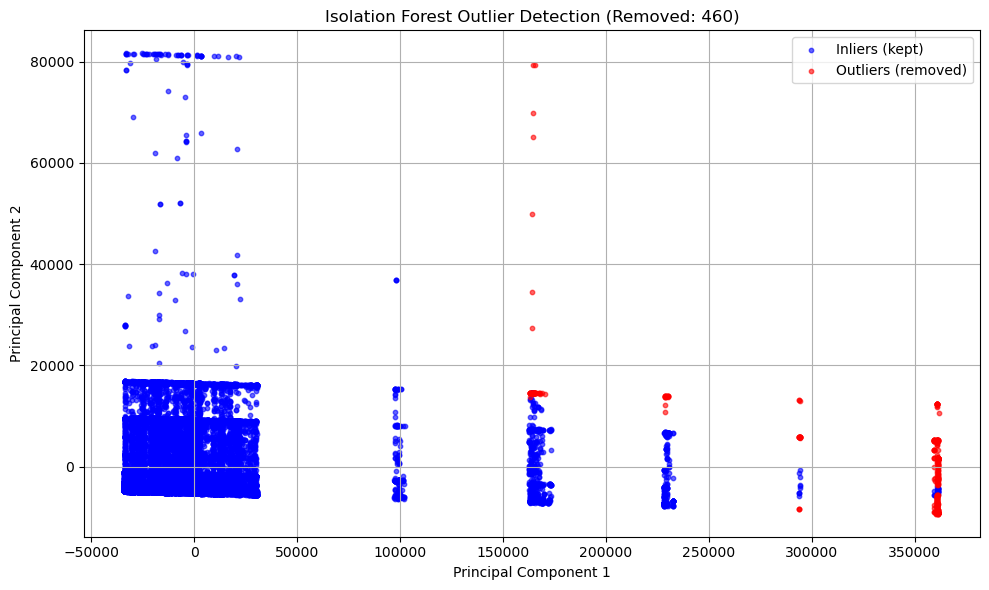

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------- Step 1: Outlier Detection on Original Training Data ---------
iso = IsolationForest(contamination=0.01, random_state=42)
outlier_preds = iso.fit_predict(X_train)

# Identify and count outliers
mask = outlier_preds == 1  # 1 = inlier, -1 = outlier
num_outliers = (~mask).sum()

# Apply the same mask to both X_train and y_train
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

print(f"Outliers removed from training set: {num_outliers}")
print(f"New training shapes: X_train={X_train.shape}, y_train={y_train.shape}")


# --------- Step 2: Apply PCA for Visualization ---------
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Re-run IsolationForest just for visualization on PCA-reduced data
iso_vis = IsolationForest(contamination=0.01, random_state=42)
outlier_preds_vis = iso_vis.fit_predict(X_train_pca)

# --------- Step 3: Visualization ---------
plt.figure(figsize=(10, 6))
plt.scatter(
    X_train_pca[outlier_preds_vis == 1, 0],
    X_train_pca[outlier_preds_vis == 1, 1],
    c='blue', label='Inliers (kept)', s=10, alpha=0.6
)
plt.scatter(
    X_train_pca[outlier_preds_vis == -1, 0],
    X_train_pca[outlier_preds_vis == -1, 1],
    c='red', label='Outliers (removed)', s=10, alpha=0.6
)
plt.title(f"Isolation Forest Outlier Detection (Removed: {num_outliers})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
from sklearn.feature_selection import VarianceThreshold

# Record original number of features
original_feature_count = X_train.shape[1]

# Apply Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_reduced = pd.DataFrame(selector.fit_transform(X_train), columns=X_train.columns[selector.get_support()])
X_test_reduced = pd.DataFrame(selector.transform(X_test), columns=X_test.columns[selector.get_support()])

# Get number of features after selection
reduced_feature_count = X_train_reduced.shape[1]
features_removed = original_feature_count - reduced_feature_count

# Print results
print("\n----------Remove Low-Variance Features----------")
print(f"Number of features after variance thresholding: {reduced_feature_count}")
print(f"Number of features removed: {features_removed}")


----------Remove Low-Variance Features----------
Number of features after variance thresholding: 79
Number of features removed: 12


In [11]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.8)]

X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)
print("\n----------Correlation Analysis----------")
print(f"Highly correlated features removed: {len(high_corr_features)}")



----------Correlation Analysis----------
Highly correlated features removed: 37


In [12]:
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [13]:
# Ensure X_train and y_train have aligned and clean indexes
X_train = X_train.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)

In [14]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# ---------- INPUT ----------
# X_train: preprocessed feature matrix (shape: [n_samples, 55])
# y_train: binary target vector

# 1. Compute Feature Importance Scores
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = pd.Series(mi_selector.scores_, index=X_train.columns)
mi_rank = mi_scores.rank(ascending=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_rank = rf_scores.rank(ascending=False)

perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X_train.columns)
perm_rank = perm_scores.rank(ascending=False)

# 2. Aggregate rankings (weighted sum)
combined_rank = 0.4 * mi_rank + 0.3 * rf_rank + 0.3 * perm_rank
sorted_features = combined_rank.sort_values().index.tolist()

# 3. Evaluation function (maximize recall, reduce FPR)
def evaluate_feature_subset(feature_list, X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    recalls = []
    fprs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx][feature_list], X.iloc[val_idx][feature_list]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        y_pred = model.predict(X_val_cv)
        recall = recall_score(y_val_cv, y_pred)

        # Calculate FPR
        tn, fp, fn, tp = confusion_matrix(y_val_cv, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0.0

        recalls.append(recall)
        fprs.append(fpr)

    avg_recall = np.mean(recalls)
    avg_fpr = np.mean(fprs)
    score = (0.6 * avg_recall) + (0.4 * (1 - avg_fpr))  # custom weighted score
    return score, avg_recall, avg_fpr

# 4. Grid search top-k
best_k = 0
best_score = 0
best_recall = 0
best_fpr = 1.0

for k in range(10, 40, 5):  # Try top-10 to top-50 features
    top_k_features = sorted_features[:k]
    score, avg_recall, avg_fpr = evaluate_feature_subset(top_k_features, X_train, y_train)

    print(f"Top-{k} | Score: {score:.4f} | Recall: {avg_recall:.4f} | FPR: {avg_fpr:.4f}")

    if score > best_score:
        best_k = k
        best_score = score
        best_recall = avg_recall
        best_fpr = avg_fpr

# 5. Final selected features
final_features = sorted_features[:best_k]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

# 6. Output
print(f"\nSelected Top-{best_k} Features (Score = {best_score:.4f}, Recall = {best_recall:.4f}, FPR = {best_fpr:.4f}):")
for i, feat in enumerate(final_features, 1):
    print(f"{i}. {feat}")

Top-10 | Score: 0.9488 | Recall: 0.9574 | FPR: 0.0641
Top-15 | Score: 0.9518 | Recall: 0.9591 | FPR: 0.0591
Top-20 | Score: 0.9541 | Recall: 0.9605 | FPR: 0.0555
Top-25 | Score: 0.9551 | Recall: 0.9612 | FPR: 0.0540
Top-30 | Score: 0.9558 | Recall: 0.9619 | FPR: 0.0532
Top-35 | Score: 0.9554 | Recall: 0.9615 | FPR: 0.0536

Selected Top-30 Features (Score = 0.9558, Recall = 0.9619, FPR = 0.0532):
1. directory_length
2. length_url
3. time_domain_activation
4. qty_slash_url
5. file_length
6. ttl_hostname
7. asn_ip
8. qty_dot_directory
9. qty_dot_domain
10. time_domain_expiration
11. qty_hyphen_file
12. qty_hyphen_directory
13. qty_underline_directory
14. qty_equal_directory
15. time_response
16. qty_vowels_domain
17. qty_dot_url
18. qty_mx_servers
19. params_length
20. qty_ip_resolved
21. qty_nameservers
22. qty_hyphen_url
23. qty_redirects
24. qty_hyphen_params
25. tls_ssl_certificate
26. domain_spf
27. qty_equal_url
28. qty_slash_params
29. qty_percent_params
30. qty_questionmark_params

Text(0.5, 1.0, 'Feature Importance Comparison')

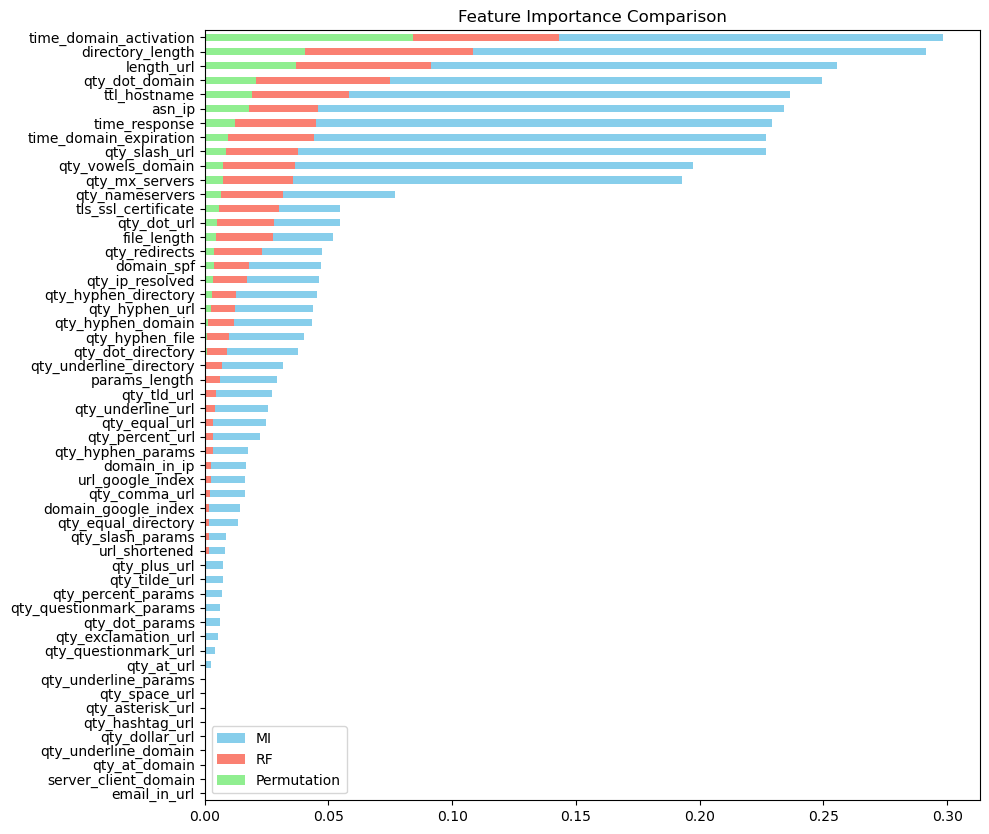

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
mi_scores.sort_values().plot(kind='barh', color='skyblue', label='MI')
rf_scores.sort_values().plot(kind='barh', color='salmon', label='RF')
perm_scores.sort_values().plot(kind='barh', color='lightgreen', label='Permutation')
plt.legend()
plt.title("Feature Importance Comparison")

## Hypothesis 1

30 repetitions are repeated runs on the same data.

Metrics are averaged to get a stable estimate.


In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)
from scipy.stats import ttest_rel, wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt

# ML Models
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# SECTION A — Data Preparation
# ============================================================

scaler_baseline = MinMaxScaler()
X_train_baseline = pd.DataFrame(
    scaler_baseline.fit_transform(X_train_reduced.copy()),
    columns=X_train_reduced.columns
)
X_test_baseline = pd.DataFrame(
    scaler_baseline.transform(X_test_reduced.copy()),
    columns=X_test_reduced.columns
)

X_train_selected = X_train_final.copy()
X_test_selected = X_test_final.copy()

print(f"Baseline Features : {X_train_baseline.shape[1]}")
print(f"Selected Features : {X_train_selected.shape[1]}")
print(f"Reduction         : {(1 - X_train_selected.shape[1]/X_train_baseline.shape[1])*100:.2f}%")

Baseline Features : 79
Selected Features : 30
Reduction         : 62.03%


C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\1827310076.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


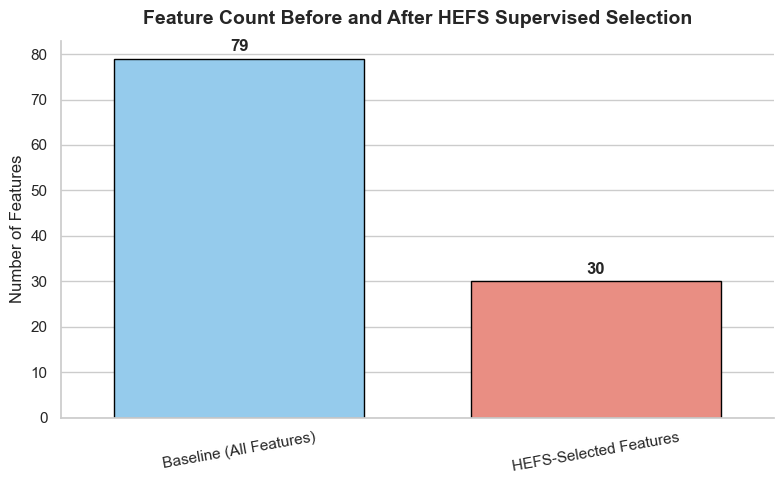

,Setting,Num_Features
0,Baseline (All Features),79
1,HEFS-Selected Features,30


In [38]:
# ============================================================
# VIS 1 — Feature Count Comparison (Salmon Theme, FIXED SPACING)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Data
feature_counts = pd.DataFrame({
    "Setting": ["Baseline (All Features)", "HEFS-Selected Features"],
    "Num_Features": [X_train_baseline.shape[1], X_train_selected.shape[1]]
})

# Bigger and wider figure → fixes weird spacing
plt.figure(figsize=(8, 5))

# Better palette (skyblue + salmon)
palette = ["#87CEFA", "#FA8072"]

ax = sns.barplot(
    data=feature_counts,
    x="Setting",
    y="Num_Features",
    palette=palette,
    width=0.7,             # <-- wider bar solves the weird shape
    edgecolor="black",
    linewidth=1
)

# Title
plt.title(
    "Feature Count Before and After HEFS Supervised Selection",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.ylabel("Number of Features", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=10, fontsize=11)

# Value labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(feature_counts["Num_Features"]) * 0.02,
        f"{int(height)}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

feature_counts


Paired t-test (safe_ttest): Tests if the mean difference of a metric (e.g., accuracy, F1) between the baseline and selected model is significantly different from zero.

Wilcoxon Signed-Rank Test (safe_wilcoxon): robust check of statistical significance.

Cohen’s d (safe_cohen_d): Measures effect size, i.e., practical magnitude of the difference between baseline and selected model.

Bootstrap Confidence Interval (bootstrap_ci): range where true mean difference likely falls.

In [17]:
# ============================================================
# SECTION B — Advanced Evaluation
# ============================================================

def bootstrap_ci(data, ci=95, n_boot=3000):
    boot = np.random.choice(data, size=(n_boot, len(data)), replace=True).mean(axis=1)
    low = np.percentile(boot, (100-ci)/2)
    high = np.percentile(boot, 100 - (100-ci)/2)
    return (low, high)

def evaluate_model_once(model, X_train, X_test, y_train, y_test):
    t0 = time.time()
    model.fit(X_train, y_train)
    t1 = time.time()

    p0 = time.time()
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    p1 = time.time()

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn)  # False Positive Rate

    return {
        "train_time": t1 - t0,
        "predict_time": (p1 - p0) / len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "fpr": fpr
    }

def evaluate_repeated(model, X_train, X_test, y_train, y_test, runs=30):
    metrics = {
        "train": [], "predict": [],
        "accuracy": [], "precision": [], "recall": [],
        "f1": [], "auc": [], "fpr": []
    }

    for _ in range(runs):
        result = evaluate_model_once(model, X_train, X_test, y_train, y_test)
        for k in metrics.keys():
            metrics[k].append(result[k if k not in ["train","predict"] else k+"_time" if k in ["train","predict"] else k])

    return metrics

In [19]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Add, Input, Flatten
from tensorflow.keras.models import Model
from xgboost import XGBClassifier

def residual_block(x, filters, kernel_size=3, dilation_rate=1, dropout_rate=0.2):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding="causal",
               dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)
    x = Conv1D(filters, kernel_size, padding="causal",
               dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([shortcut, x])
    x = Activation("relu")(x)
    return x

def create_fnn_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))   # first hidden layer
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))                       # second hidden layer
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_tcn_model(input_dim):
    inp = Input(shape=(input_dim, 1))
    x = residual_block(inp, 64, dilation_rate=1)
    x = residual_block(x, 64, dilation_rate=2)
    x = residual_block(x, 64, dilation_rate=4)

    x = Flatten()(x)

    x = Dense(64,  activation="relu")(x)   # first hidden layer
    x = Dropout(0.2)(x)
    x = Dense(128, activation="relu")(x)   # second hidden layer
    x = Dropout(0.3)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def create_cnn_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))   # first hidden layer
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))                       # second hidden layer
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.01),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

fnn_baseline = KerasClassifier(
    build_fn=lambda: create_fnn_model(X_train_baseline.shape[1]),
    epochs=10, batch_size=32, verbose=1
)
fnn_selected = KerasClassifier(
    build_fn=lambda: create_fnn_model(X_train_selected.shape[1]),
    epochs=10, batch_size=32, verbose=1
)

cnn_baseline = KerasClassifier(
    build_fn=lambda: create_cnn_model(X_train_baseline.shape[1]),
    epochs=10, batch_size=32, verbose=0
)
cnn_selected = KerasClassifier(
    build_fn=lambda: create_cnn_model(X_train_selected.shape[1]),
    epochs=10, batch_size=32, verbose=0
)

tcn_baseline = KerasClassifier(
    build_fn=lambda: create_tcn_model(X_train_baseline.shape[1]),
    epochs=10, batch_size=32, verbose=0
)
tcn_selected = KerasClassifier(
    build_fn=lambda: create_tcn_model(X_train_selected.shape[1]),
    epochs=10, batch_size=32, verbose=0
)

models = {
    "FNN": (fnn_baseline, fnn_selected),
    "CNN": (cnn_baseline, cnn_selected),
    "TCN": (tcn_baseline, tcn_selected),
    "RF":  (RandomForestClassifier(random_state=42),
            RandomForestClassifier(random_state=42)),
    "XGBoost": (XGBClassifier(random_state=42),
                XGBClassifier(random_state=42))
}

results_all = []

print("\nRunning 30 repetitions per model...\n")

for name, (model_base, model_sel) in models.items():
    print(f"Evaluating: {name}")

    baseline = evaluate_repeated(model_base,
                                 X_train_baseline, X_test_baseline,
                                 y_train, y_test)

    selected = evaluate_repeated(model_sel,
                                 X_train_selected, X_test_selected,
                                 y_train, y_test)

    results_all.append((name, baseline, selected))
    print(f"Completed: {name}\n")


Running 30 repetitions per model...

Evaluating: FNN
Epoch 1/10


c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1421/1421 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8686 - loss: 0.3034
Epoch 2/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8868 - loss: 0.2697
Epoch 3/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8934 - loss: 0.2586
Epoch 4/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8966 - loss: 0.2513
Epoch 5/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8989 - loss: 0.2448
Epoch 6/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9007 - loss: 0.2431
Epoch 7/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9027 - loss: 0.2377
Epoch 8/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9031 - loss: 0.2352
Epoch 9/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9040 - loss: 0.2332
Epoch 10/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9066 - loss: 0.2311
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step
Epoch 1/10


c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8716 - loss: 0.3002
Epoch 2/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8858 - loss: 0.2724
Epoch 3/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8913 - loss: 0.2601
Epoch 4/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8948 - loss: 0.2547
Epoch 5/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8978 - loss: 0.2456
Epoch 6/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9026 - loss: 0.2399
Epoch 7/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9051 - loss: 0.2349
Epoch 8/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9053 - loss: 0.2344
Epoch 9/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9061 - loss: 0.2325
Epoch 10/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9077 - loss: 0.2290
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
Epoch 1/10


...

1421/1421 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8739 - loss: 0.2978
Epoch 2/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8897 - loss: 0.2658
Epoch 3/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8980 - loss: 0.2485
Epoch 4/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8995 - loss: 0.2429
Epoch 5/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9046 - loss: 0.2358
Epoch 6/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9063 - loss: 0.2290
Epoch 7/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9090 - loss: 0.2286
Epoch 8/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9097 - loss: 0.2258
Epoch 9/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9104 - loss: 0.2243
Epoch 10/10
1421/1421 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9123 - loss: 0.2186
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
Completed: FNN

Evaluating: CNN


c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, p

Completed: CNN

Evaluating: TCN


c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\ziyan\anaconda3\Lib\site-pa

Completed: TCN

Evaluating: RF
Completed: RF

Evaluating: XGBoost
Completed: XGBoost



In [20]:
# ============================================================
# SECTION E — Robust Statistical Tests
# ============================================================

def safe_cohen_d(before, after):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)
    diff = after - before
    std_diff = np.std(diff, ddof=1)
    if std_diff == 0:
        return 0.0
    return diff.mean() / std_diff

def safe_wilcoxon(before, after):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)
    if np.all(before == after):
        return 1.0  # identical values → no difference
    try:
        stat, p = wilcoxon(before, after, zero_method='wilcox')
        return p
    except:
        return 1.0

def safe_ttest(before, after):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)
    if np.all(before == after):
        return 1.0
    return ttest_rel(before, after).pvalue

def bootstrap_ci(data, num_bootstrap=10000, ci=0.95):
    data = np.array(data, dtype=float)
    if np.std(data) == 0:
        return (data[0], data[0])
    boot_means = []
    n = len(data)
    for _ in range(num_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))
    alpha = (1 - ci) / 2
    return (np.percentile(boot_means, 100 * alpha),
            np.percentile(boot_means, 100 * (1 - alpha)))

def fmt(x):
    try:
        return f"{float(x):.4f}"
    except:
        return "0.0000"

In [25]:
rows = []

metric_map = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1 Score",
    "auc": "AUC",
    "fpr": "False Positive Rate"
}

for name, baseline, selected in results_all:
    for metric_key, label in metric_map.items():
        baseline_mean = np.mean(baseline[metric_key])
        selected_mean = np.mean(selected[metric_key])
        percent_change = ((selected_mean - baseline_mean) / baseline_mean) * 100
        
        t_p = safe_ttest(baseline[metric_key], selected[metric_key])
        w_p = safe_wilcoxon(baseline[metric_key], selected[metric_key])
        d = safe_cohen_d(baseline[metric_key], selected[metric_key])
        ci_low, ci_high = bootstrap_ci(np.array(selected[metric_key]) - np.array(baseline[metric_key]))

        rows.append([
            name,
            label,
            fmt(baseline_mean),
            fmt(selected_mean),
            f"{percent_change:+.4f}%",       # practical % change
            fmt(t_p),
            fmt(w_p),
            fmt(d),
            f"[{fmt(ci_low)}, {fmt(ci_high)}]",
            "Reject H₀" if t_p < 0.05 else "Fail to Reject H₀"
        ])

# -----------------------------
# Create DataFrame
# -----------------------------
practical_stats_df = pd.DataFrame(rows, columns=[
    "Model", "Metric",
    "Baseline Mean", "Selected Mean",
    "% Change",                  
    "T-test p", "Wilcoxon p", "Cohen d",
    "95% CI (Bootstrap)", "Conclusion"
])

# -----------------------------
# Color-Coding Functions
# -----------------------------
def color_percent_change(val):
    try:
        val_float = float(val.strip('%'))
    except:
        return ''
    if val_float > 0.01:        # Improvement
        return 'background-color: #c6efce; color: #006100'  # green
    elif val_float < -0.01:     # Degradation
        return 'background-color: #ffc7ce; color: #9c0006'  # red
    else:                        # Negligible
        return 'background-color: #f0f0f0; color: #000000'  # gray

def color_pvalue(val):
    try:
        val_float = float(val)
    except:
        return ''
    if val_float < 0.05:
        return 'background-color: #c6efce; color: #006100'  # significant → green
    else:
        return 'background-color: #f0f0f0; color: #000000'  # not significant → gray

def color_cohen_d(val):
    try:
        val_float = float(val)
    except:
        return ''
    if abs(val_float) >= 0.8:      # large effect
        return 'background-color: #c6efce; color: #006100'
    elif abs(val_float) >= 0.5:    # medium effect
        return 'background-color: #ffeb9c; color: #9c5700'
    else:                           # small/negligible
        return 'background-color: #f0f0f0; color: #000000'

# -----------------------------
# Apply Styling
# -----------------------------
styled_df = practical_stats_df.style \
    .applymap(color_percent_change, subset=['% Change']) \
    .applymap(color_pvalue, subset=['T-test p', 'Wilcoxon p']) \
    .applymap(color_cohen_d, subset=['Cohen d']) \
    .set_caption("FINAL FEATURE SELECTION SUMMARY TABLE") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'),
                   ('font-size', '16px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('margin-bottom', '10px')]}
    ])

# -----------------------------
# Display Styled Table
# -----------------------------
display(styled_df)


c:\Users\ziyan\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2046824396.py:88: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_percent_change, subset=['% Change']) \
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2046824396.py:89: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pvalue, subset=['T-test p', 'Wilcoxon p']) \
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2046824396.py:90: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_cohen_d, subset=['Cohen d']) \


,Model,Metric,Baseline Mean,Selected Mean,% Change,T-test p,Wilcoxon p,Cohen d,95% CI (Bootstrap),Conclusion
0,FNN,Accuracy,0.9165,0.9227,+0.6687%,0.0000,0.0000,1.0547,"[0.0040, 0.0081]",Reject H₀
1,FNN,Precision,0.9155,0.9266,+1.2128%,0.0094,0.0327,0.5083,"[0.0035, 0.0191]",Reject H₀
2,FNN,Recall,0.9292,0.9285,-0.0741%,0.8723,0.9032,-0.0296,"[-0.0091, 0.0074]",Fail to Reject H₀
3,FNN,F1 Score,0.9221,0.9273,+0.5675%,0.0000,0.0001,0.9845,"[0.0033, 0.0070]",Reject H₀
4,FNN,AUC,0.9758,0.9785,+0.2809%,0.0000,0.0000,1.6407,"[0.0021, 0.0033]",Reject H₀
5,FNN,False Positive Rate,0.0978,0.0839,-14.1735%,0.0157,0.0473,-0.4687,"[-0.0243, -0.0038]",Reject H₀
6,CNN,Accuracy,0.9145,0.9214,+0.7582%,0.0000,0.0000,0.9645,"[0.0044, 0.0095]",Reject H₀
7,CNN,Precision,0.9144,0.9218,+0.8028%,0.1538,0.0961,0.2674,"[-0.0023, 0.0171]",Fail to Reject H₀
8,CNN,Recall,0.9265,0.9317,+0.5616%,0.2803,0.3818,0.2009,"[-0.0040, 0.0141]",Fail to Reject H₀
9,CNN,F1 Score,0.9201,0.9264,+0.6946%,0.0000,0.0000,1.0855,"[0.0043, 0.0085]",Reject H₀


C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:47: UserWarning: set_ticklabels(

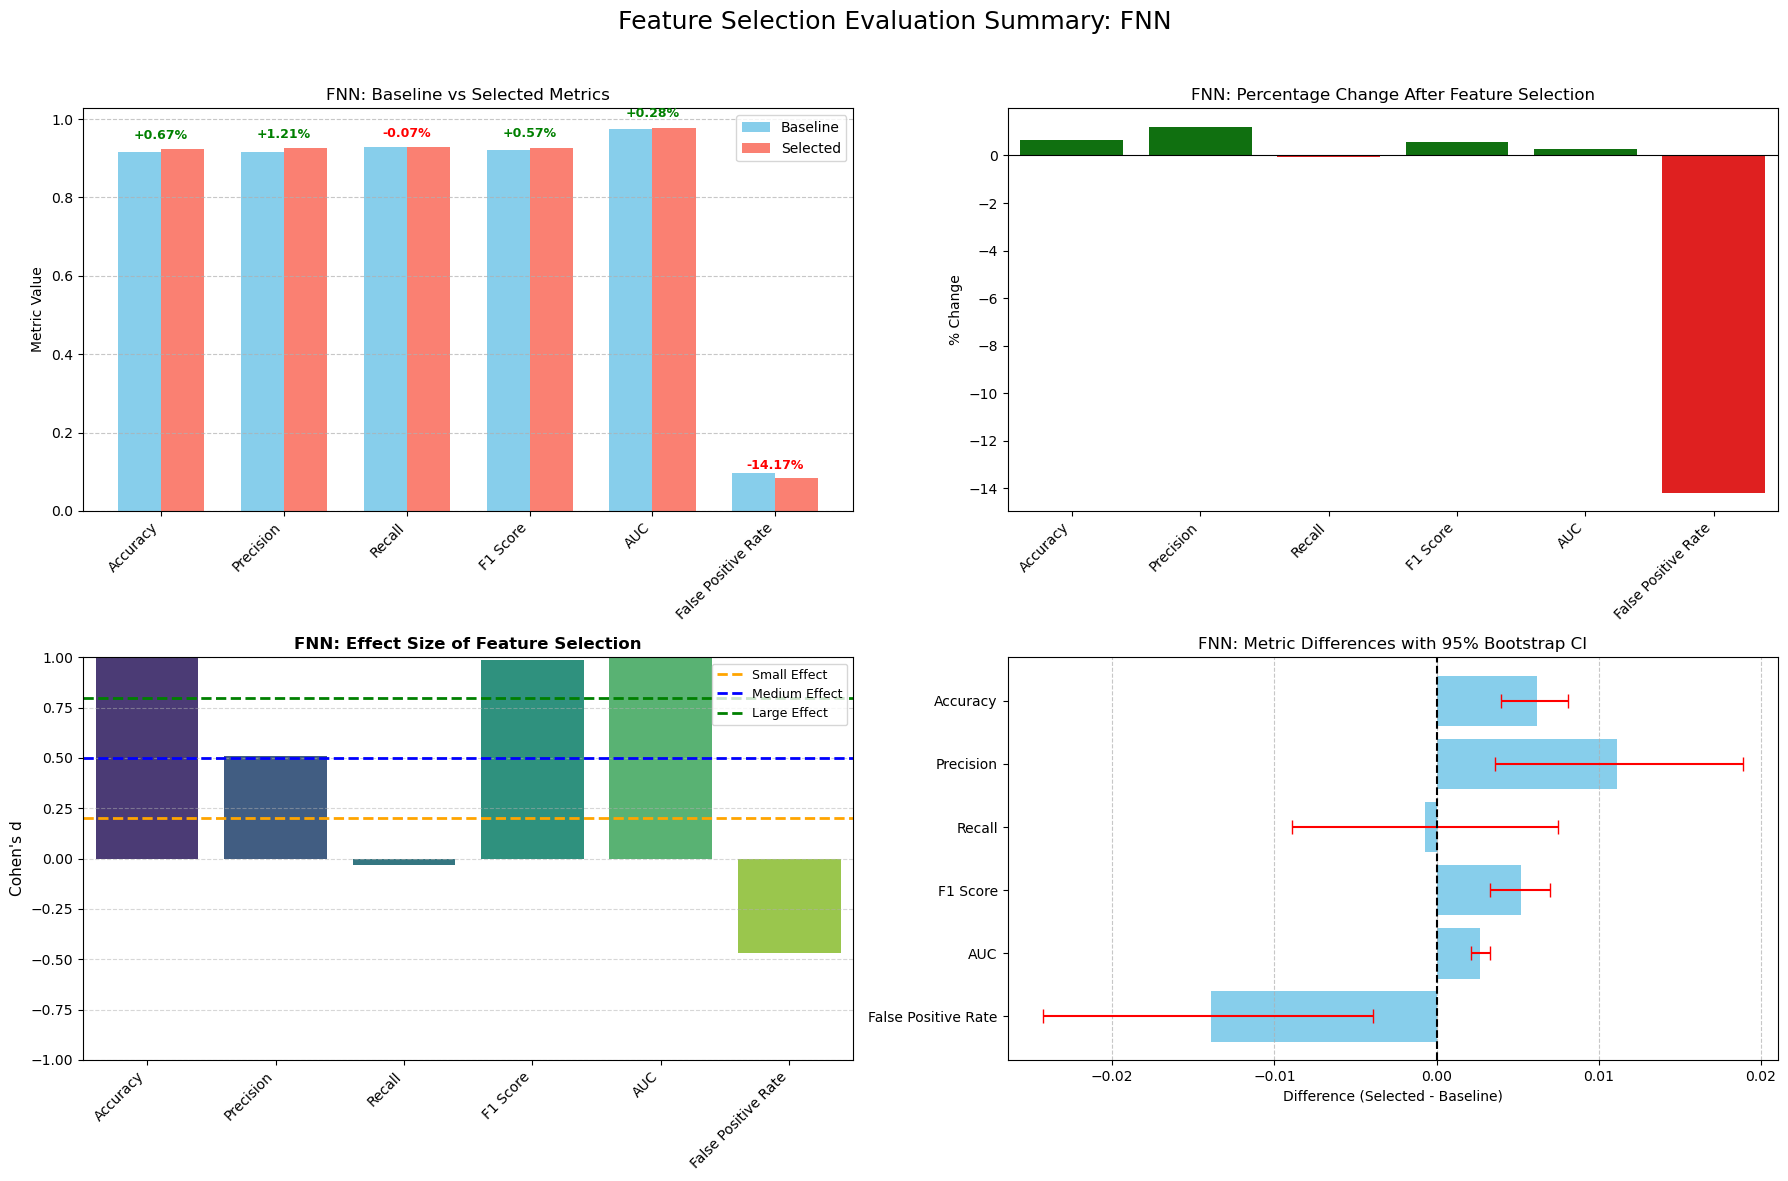

C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:47: UserWarning: set_ticklabels(

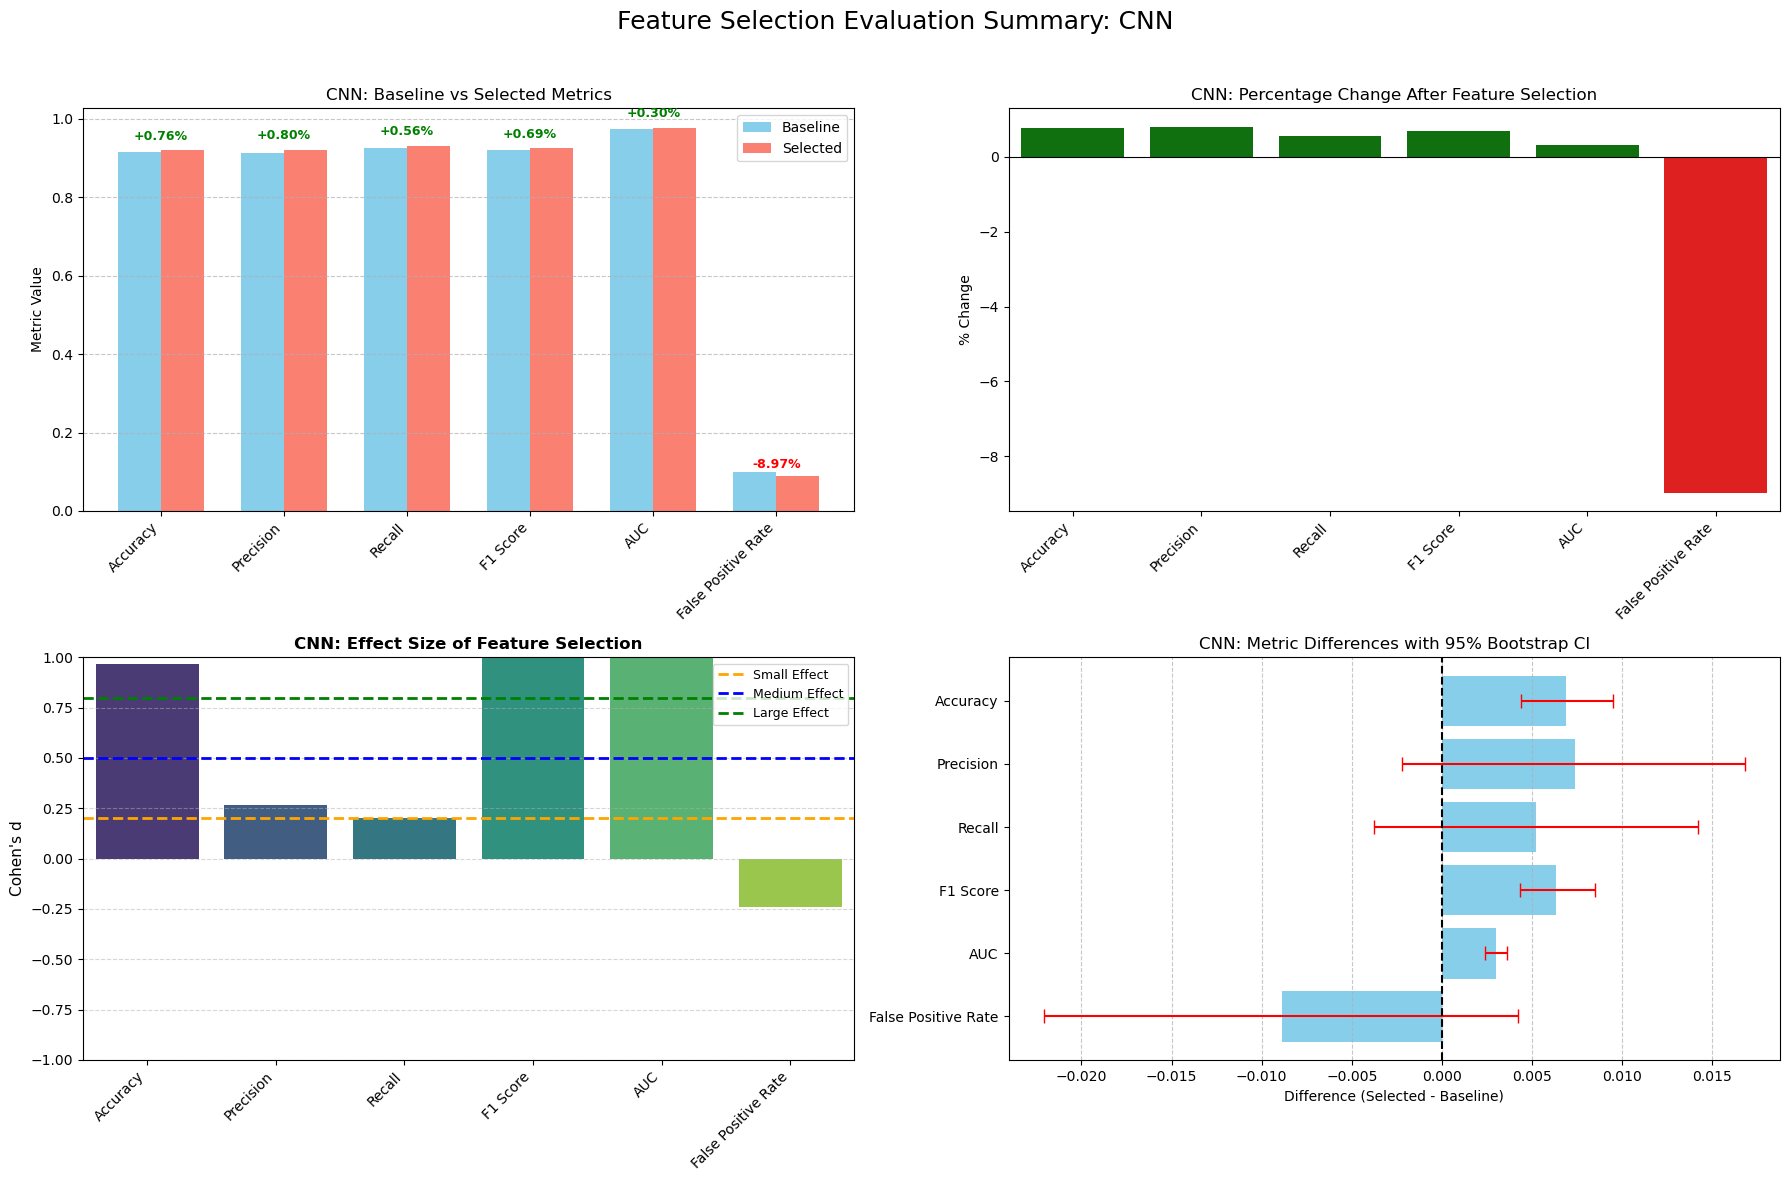

C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:47: UserWarning: set_ticklabels(

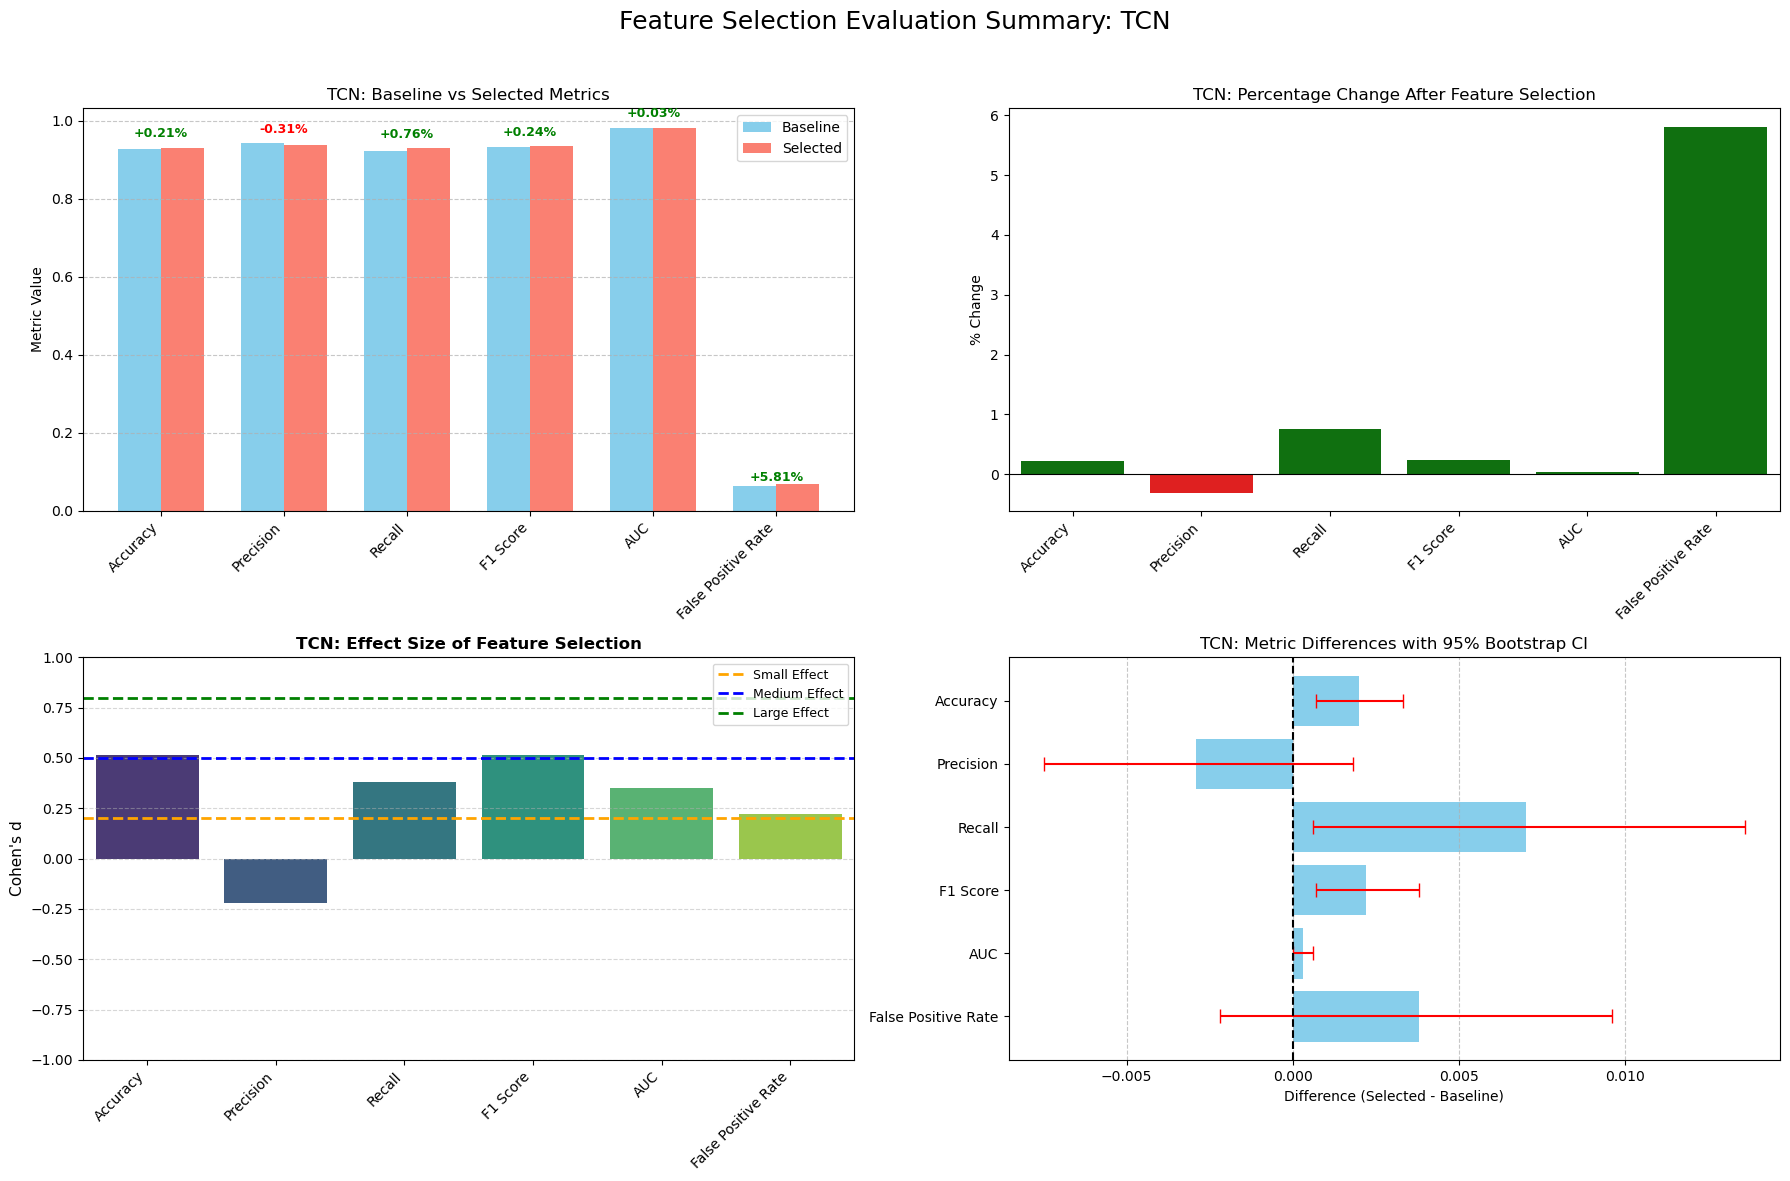

C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:47: UserWarning: set_ticklabels(

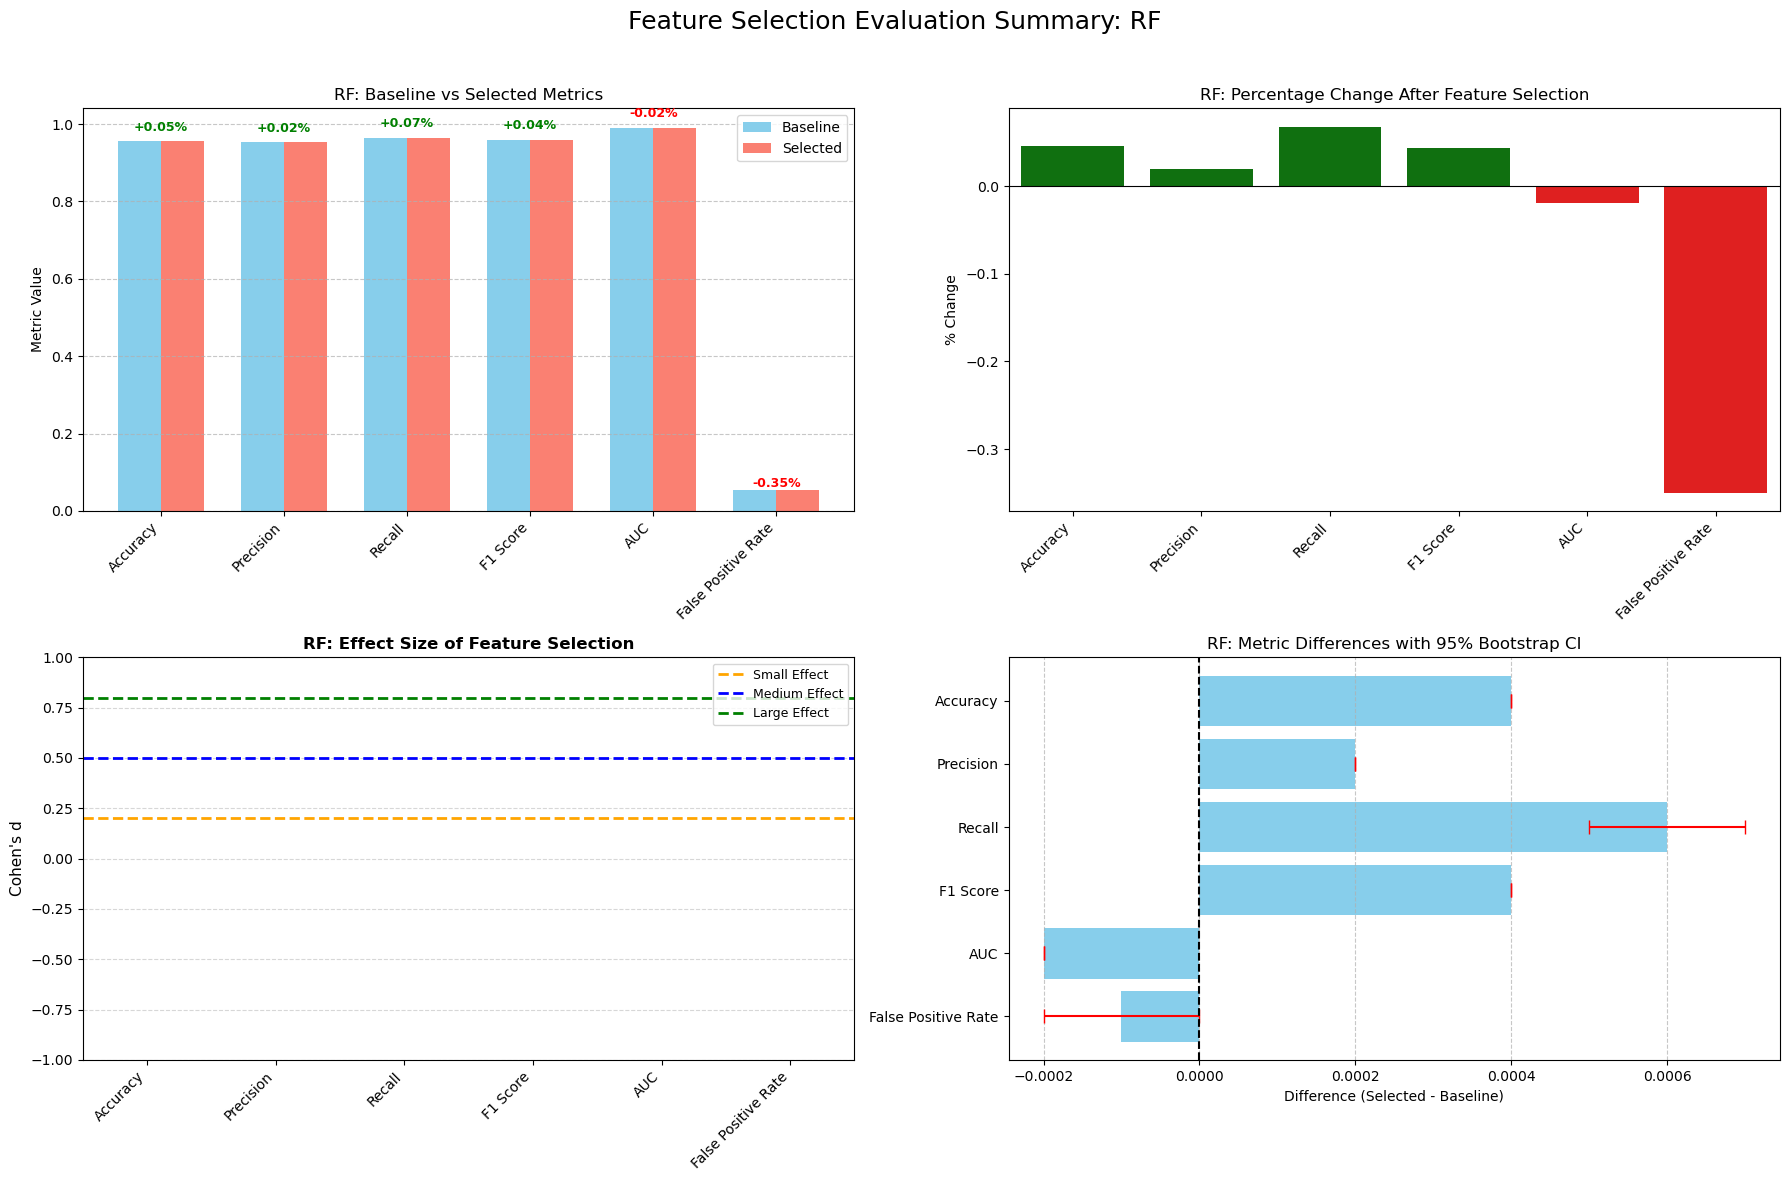

C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
C:\Users\ziyan\AppData\Local\Temp\ipykernel_58072\2102129264.py:47: UserWarning: set_ticklabels(

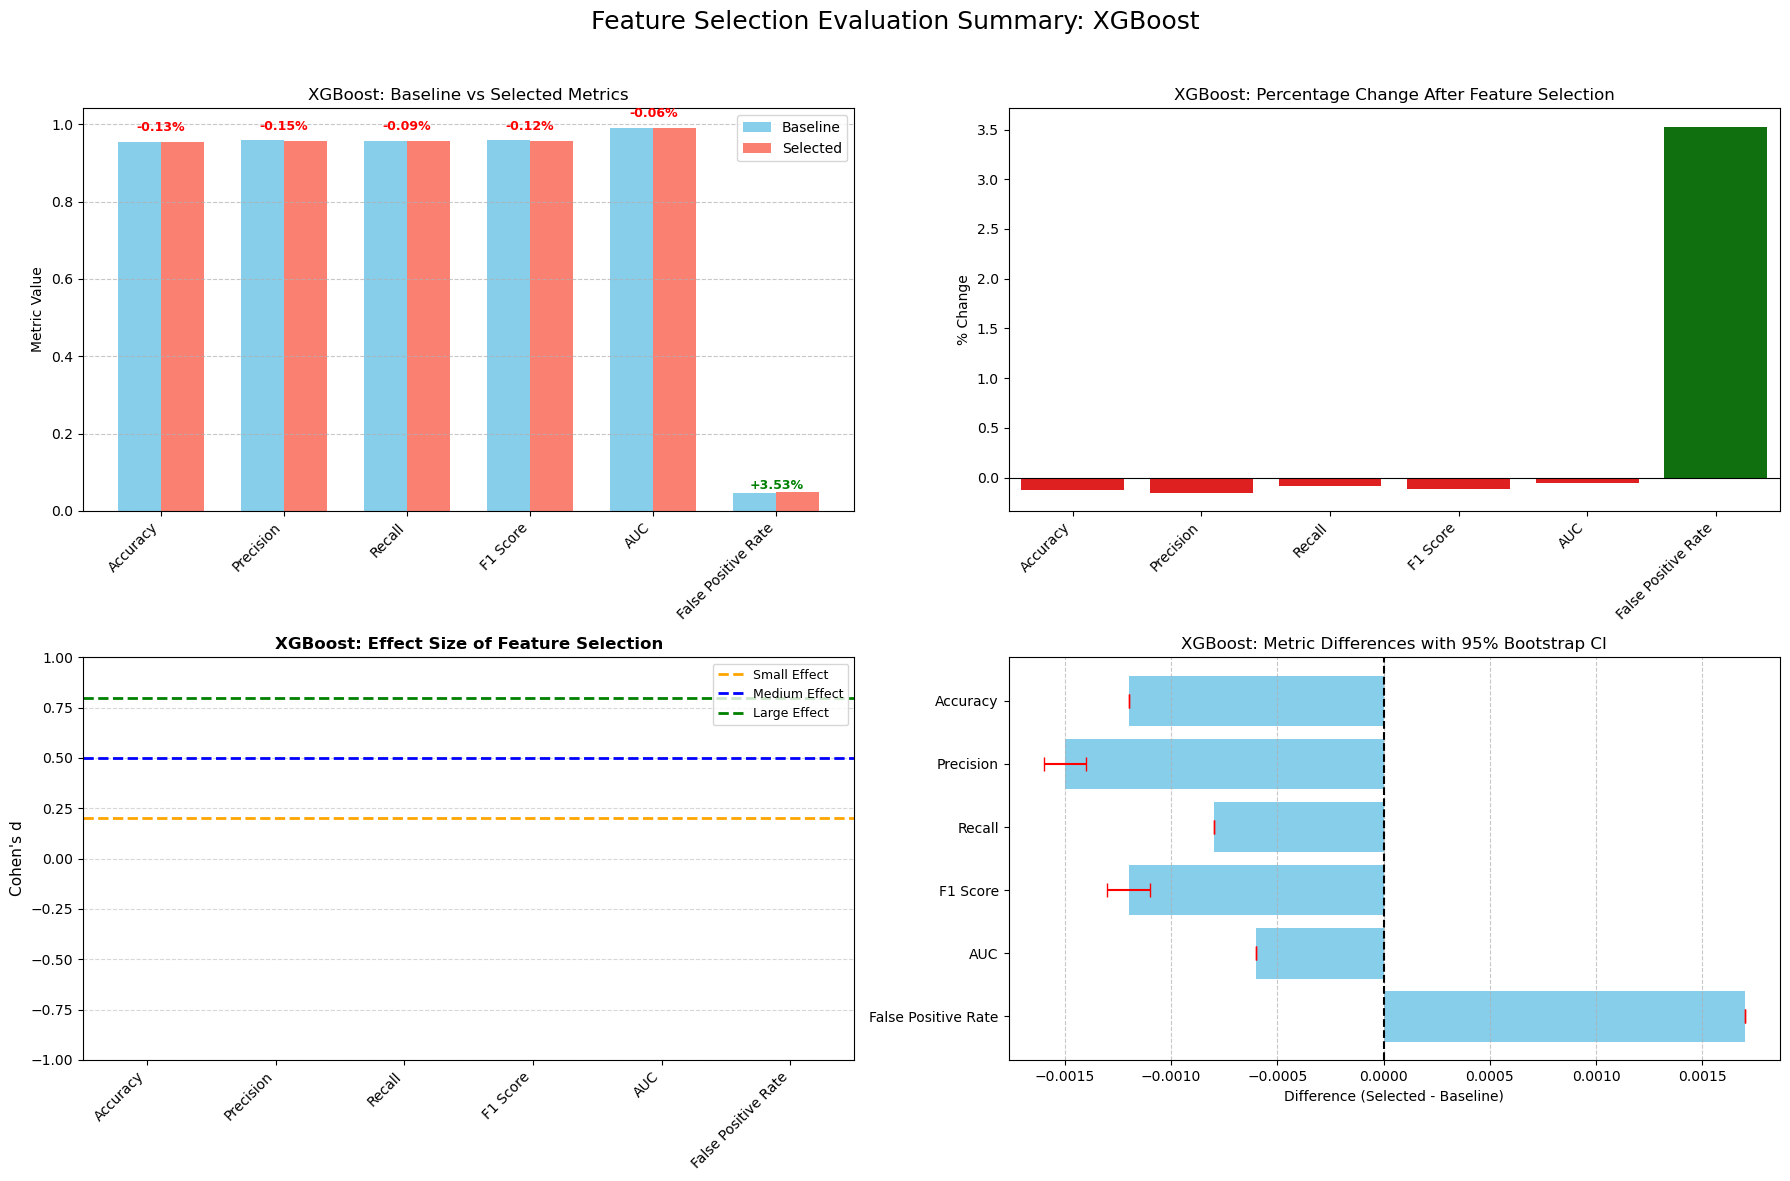

In [23]:
for model in practical_stats_df['Model'].unique():
    df = practical_stats_df[practical_stats_df['Model'] == model]
    metrics = df['Metric'].tolist()
    baseline_means = df['Baseline Mean'].astype(float)
    selected_means = df['Selected Mean'].astype(float)
    percent_changes = df['% Change'].str.rstrip('%').astype(float)
    cohens_d = df['Cohen d'].astype(float)
    ci_lower = df['95% CI (Bootstrap)'].apply(lambda x: float(x.split(',')[0].strip('[')))
    ci_upper = df['95% CI (Bootstrap)'].apply(lambda x: float(x.split(',')[1].strip(']')))
    diff_mean = selected_means - baseline_means

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    x = np.arange(len(metrics))
    width = 0.35

    # 1. Absolute Metric Comparison
    axes[0,0].bar(x - width/2, baseline_means, width, label='Baseline', color='skyblue')
    axes[0,0].bar(x + width/2, selected_means, width, label='Selected', color='salmon')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[0,0].set_ylabel('Metric Value')
    axes[0,0].set_title(f'{model}: Baseline vs Selected Metrics')
    axes[0,0].legend()
    axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)
    for i, (base, sel, pct) in enumerate(zip(baseline_means, selected_means, percent_changes)):
        color = 'green' if pct > 0 else 'red'
        axes[0,0].text(i, max(base, sel) * 1.02, f'{pct:+.2f}%', 
                       ha='center', va='bottom', fontweight='bold', color=color, fontsize=9)

    # 2. Percent Change
    colors = ['green' if v>0 else 'red' for v in percent_changes]
    sns.barplot(x=metrics, y=percent_changes, palette=colors, ax=axes[0,1])
    axes[0,1].axhline(0, color='black', linewidth=0.8)
    axes[0,1].set_ylabel('% Change')
    axes[0,1].set_title(f'{model}: Percentage Change After Feature Selection')
    axes[0,1].set_xticklabels(metrics, rotation=45, ha='right')

    # 3. Cohen's d Effect Size
    sns.barplot(x=metrics, y=cohens_d, palette='viridis', ax=axes[1,0])
    axes[1,0].axhline(0.2, color='orange', linestyle='--', linewidth=2, label='Small Effect')
    axes[1,0].axhline(0.5, color='blue', linestyle='--', linewidth=2, label='Medium Effect')
    axes[1,0].axhline(0.8, color='green', linestyle='--', linewidth=2, label='Large Effect')
    axes[1,0].set_ylim(-1, 1)
    axes[1,0].set_ylabel("Cohen's d", fontsize=11)
    axes[1,0].set_title(f"{model}: Effect Size of Feature Selection", fontsize=12, fontweight='bold')
    axes[1,0].set_xticklabels(metrics, rotation=45, ha='right')
    axes[1,0].legend(loc='upper right', fontsize=9)
    axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)

    # 4. Difference with 95% CI
    y_pos = np.arange(len(metrics))
    yerr_lower = np.abs(diff_mean - ci_lower)
    yerr_upper = np.abs(ci_upper - diff_mean)
    axes[1,1].barh(y_pos, diff_mean, xerr=[yerr_lower, yerr_upper],
                   color='skyblue', ecolor='red', capsize=5)
    axes[1,1].axvline(0, color='black', linestyle='--')
    axes[1,1].set_yticks(y_pos)
    axes[1,1].set_yticklabels(metrics)
    axes[1,1].set_xlabel('Difference (Selected - Baseline)')
    axes[1,1].set_title(f'{model}: Metric Differences with 95% Bootstrap CI')
    axes[1,1].invert_yaxis()
    axes[1,1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.suptitle(f'Feature Selection Evaluation Summary: {model}', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
